# Tree-Based Models & Ensembles — Assignment Notebook
### Week 5 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right tool, parameter, or formula and justify why.

---


In [ ]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, f1_score,
                             recall_score, precision_score, roc_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.datasets import make_moons
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap, joblib

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [11, 5]

# Load the Telco dataset (used from Section 2 onwards)
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
print(f"Dataset loaded: {df_raw.shape}"); print(df_raw.dtypes.tail(6))


---
## Section 1: Decision Tree Building Blocks

Before using sklearn, prove you understand what a tree *actually does* by implementing the core math yourself.

---

### Q1 — Implement Gini Impurity from Scratch

A Decision Tree evaluates every candidate split by measuring how *impure* the resulting child nodes are. Gini is the most common measure.

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

where $p_k$ is the fraction of samples belonging to class $k$ at node $t$.

**Your task:** Complete the function below. Do not use any sklearn or numpy impurity functions — implement the formula directly.


In [ ]:
def gini_impurity(class_counts):
    """
    Compute Gini impurity for a single node.

    Parameters
    ----------
    class_counts : list or array of ints
        Number of samples per class at this node.
        e.g. [70, 30] means 70 samples of class-0, 30 of class-1

    Returns
    -------
    float : Gini value in [0, 0.5] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0
def gini_impurity(class_counts):
    total = sum(class_counts)
    if total == 0:
        return 0.0
    sum_sq = 0.0
    for c in class_counts:
        p = c / total
        sum_sq += p * p
    return 1 - sum_sq
    # YOUR CODE HERE
    # Hint: compute p_k for each class, then apply the Gini formula
    gini = None
    raise NotImplementedError("Implement gini_impurity()")
    return gini


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(gini_impurity([100, 0])   - 0.000) < 1e-6, "Pure node should have Gini = 0"
assert abs(gini_impurity([50,  50])  - 0.500) < 1e-6, "Equal split should have Gini = 0.5"
assert abs(gini_impurity([70,  30])  - 0.420) < 1e-6, "70/30 split should have Gini = 0.42"
assert abs(gini_impurity([10,  10, 10]) - round(1 - 3*(1/3)**2, 6)) < 1e-5, "3-class test failed"
print("✅ All gini_impurity checks passed!")


### Q2 — Implement Shannon Entropy

Entropy is the alternative impurity measure. It measures *information* rather than probability of mislabelling.

$$H(t) = -\sum_{k} p_k \log_2(p_k)$$

**Convention:** $0 \cdot \log_2(0) = 0$ (a class with zero samples contributes nothing).


In [ ]:
import numpy as np # Ensure numpy is imported for np.log2
def entropy(class_counts):
    """
    Compute Shannon entropy for a single node.

    Returns
    -------
    float : entropy in [0, 1] for binary classification
    """
    total = sum(class_counts)
    if total == 0:
        return 0.0

    # YOUR CODE HERE
    # Hint: use math.log2 or np.log2; skip terms where p_k == 0
    h = 0.0
    for count in class_counts:
        if count == 0:
            continue
        p_k = count / total
        h -= p_k * np.log2(p_k)
    # raise NotImplementedError("Implement entropy()")
    return h


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert abs(entropy([100, 0])  - 0.000) < 1e-6, "Pure node should have H = 0"
assert abs(entropy([50,  50]) - 1.000) < 1e-6, "Equal binary split should have H = 1"
assert abs(entropy([70,  30]) - (-0.7*np.log2(0.7) - 0.3*np.log2(0.3))) < 1e-5
print("✅ All entropy checks passed!")

### Q3 — Compute Information Gain for a Candidate Split

A tree picks the split that maximises **Information Gain**:

$$\text{IG} = H(\text{parent}) - \sum_{c} \frac{n_c}{n} H(\text{child}_c)$$

**Scenario:** At a node with 1,000 samples (730 non-churners, 270 churners), you are evaluating a split on `Contract_Type`:
- Left child: 600 samples, 510 non-churn / 90 churn
- Right child: 400 samples, 220 non-churn / 180 churn

**Your task:** Use your `entropy()` function to compute the information gain of this split.


In [ ]:
# Use your entropy() function from Q2.
# Fill in the four variables below — do not hard-code the IG formula output.

parent_counts = [730, 270]      # [non-churn, churn] at the parent node
left_counts   = [510,  90]      # counts in the left child
right_counts  = [220, 180]      # counts in the right child

n_total = sum(parent_counts)
n_left  = sum(left_counts)
n_right = sum(right_counts)

# YOUR CODE HERE — compute information gain using your entropy() function
parent_entropy   = entropy(parent_counts)   # H of the parent node
weighted_entropy = (n_left / n_total) * entropy(left_counts) + \
                   (n_right / n_total) * entropy(right_counts)   # weighted average entropy of the two children
information_gain = parent_entropy - weighted_entropy   # IG = parent - weighted children

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert information_gain > 0, "Information gain should be positive for a useful split"
assert information_gain < parent_entropy, "IG cannot exceed parent entropy"
print(f"Parent Entropy:    {parent_entropy:.4f}")
print(f"Weighted Child H:  {weighted_entropy:.4f}")
print(f"Information Gain:  {information_gain:.4f}")
print("✅ Information gain computed correctly!")

✍️ **Reflect 1:** Look at the right child: 220 non-churn vs 180 churn.
Is this child purer or more mixed than the parent? What does a high information gain tell you about the quality of this split? Answer here:

> *Your answer:*

*The right child (220 non-churn, 180 churn) is more mixed than the parent (730 non-churn, 270 churn). The parent has about 73% non-churn, while the right child has only 55% non-churn – meaning its class distribution is closer to 50/50, so its impurity is higher.
High information gain means that the weighted average impurity of the two children is much lower than the parent’s impurity. In this split, the left child (510 non-churn, 90 churn) is very pure, which outweighs the right child’s higher impurity. So a high information gain tells us this split is effective at separating the classes, even if one child looks more mixed.*


---
## Section 2: Bias, Variance, and the Depth Problem

---

### Q4 — The Bias-Variance Curve

**Your task:** Train decision trees at depths 1 through 20 (plus `None` = unlimited) on the moons dataset. Record both training accuracy and test accuracy for each depth.

You must:
1. Fill in the `for` loop to train a tree and record both scores
2. Identify the depth with the highest test accuracy
3. Answer the reflection question


In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier # Added this import
import matplotlib.pyplot as plt # Added for plotting
import numpy as np # Added for np.argmax and plotting

X_bv, y_bv = make_moons(n_samples=800, noise=0.30, random_state=42)
X_tr_bv, X_te_bv, y_tr_bv, y_te_bv = train_test_split(
    X_bv, y_bv, test_size=0.30, random_state=42)

depths       = list(range(1, 21)) + [None]
train_scores = []
test_scores  = []

for d in depths:
    # YOUR CODE HERE
    # 1. Instantiate a DecisionTreeClassifier with max_depth=d and random_state=42
    # 2. Fit on (X_tr_bv, y_tr_bv)
    # 3. Append the training accuracy to train_scores
    # 4. Append the test accuracy to test_scores
    dt_clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_clf.fit(X_tr_bv, y_tr_bv)
    train_scores.append(dt_clf.score(X_tr_bv, y_tr_bv))
    test_scores.append(dt_clf.score(X_te_bv, y_te_bv))

# Plotting (run as-is after filling the loop)
depth_labels = [str(d) if d else '∞' for d in depths]
plt.figure(figsize=(12, 5))
plt.plot(depth_labels, train_scores, 'o-', color='crimson', lw=2, label='Train Accuracy')
plt.plot(depth_labels, test_scores,  's-', color='steelblue', lw=2, label='Test Accuracy')
plt.fill_between(range(len(depths)), train_scores, test_scores, alpha=0.10, color='orange')
plt.xlabel('Max Tree Depth'); plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Accuracy vs. Tree Depth')
plt.legend(); plt.xticks(range(len(depths)), depth_labels, rotation=45)
plt.tight_layout(); plt.show()

best_depth_idx = int(np.argmax(test_scores))
print(f"Best test accuracy at depth = {depth_labels[best_depth_idx]}: {test_scores[best_depth_idx]:.4f}")
print(f"Train acc at depth=∞: {train_scores[-1]:.4f}   Test acc at depth=∞: {test_scores[-1]:.4f}")
print(f"Variance gap at depth=∞: {train_scores[-1] - test_scores[-1]:.4f}")


✍️ **Reflect 2:** The unlimited-depth tree achieves ~100% training accuracy.
- What is the name of this phenomenon?
- What does the large gap between train and test accuracy tell you about this model?
- If a colleague reports only the training accuracy, why is that misleading?


Name of this phenomenon: Overfitting (high variance).

What the large gap tells us: The model has memorized the training data, including its noise, and fails to generalize to unseen data. It performs perfectly on training but poorly on test.

Why reporting only training accuracy is misleading: A colleague might think the model is perfect (100% accuracy), but in reality it is useless on new customers. The business would deploy a model that makes many wrong predictions, leading to poor retention decisions.




---
## Section 3: Data Prep & The Accuracy Trap

---

### Q5 — Fix the Telco Dataset

The raw Telco CSV has a well-known data quality issue: `TotalCharges` contains whitespace strings where the value is missing, which forces pandas to read the entire column as `object` (string) instead of `float`.

**Your task:** Fix this in three steps — detect, coerce, and impute.


In [ ]:
df = df_raw.copy()

# Step 1 — Count rows with whitespace in TotalCharges
n_whitespace = (df['TotalCharges'].str.strip() == '').sum()
print(f"Rows with whitespace TotalCharges: {n_whitespace}")

# Step 2 — Fix: coerce to numeric, then impute with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
median_val = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_val)

# Step 3 — Encode target and drop customerID
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df['TotalCharges'].dtype in [np.float64, np.float32, float], \
    f"TotalCharges should be float, got {df['TotalCharges'].dtype}"
assert df['TotalCharges'].isnull().sum() == 0, "No NaN should remain after imputation"
assert set(df['Churn'].unique()) == {0, 1}, "Churn should be binary int"
print(f"✅ Dataset clean. Shape: {df.shape}")
print(f"   Churn rate: {df['Churn'].mean()*100:.1f}%")

### Q6 — The Naive Tree and The Trap

Train an **unconstrained** DecisionTreeClassifier on the Telco data (use simple label-encoding for speed — proper pipelines come later).

Then deliberately evaluate it using **only accuracy** first. Then expose the trap by looking at the full report.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report # Added these imports
import numpy as np # Already present, but good to ensure
# Quick label encoding for the naive baseline
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = df_enc[col].astype('category').cat.codes

X_naive = df_enc.drop('Churn', axis=1)
y_naive = df_enc['Churn']

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# Train an unconstrained DecisionTreeClassifier
naive_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
naive_tree.fit(X_tr_n, y_tr_n)
y_pred_n = naive_tree.predict(X_te_n)

# ── Print results ──────────────────────────────────────────────
train_acc = accuracy_score(y_tr_n, naive_tree.predict(X_tr_n))
test_acc  = accuracy_score(y_te_n, y_pred_n)

print("=" * 55)
print(f"  Plain Accuracy (The Trap): {test_acc:.4f}")
print("=" * 55)
print(f"  Tree Depth:    {naive_tree.get_depth()}")
print(f"  Train Acc:     {train_acc:.4f}")
print(f"  Test Acc:      {test_acc:.4f}")
print(f"  Variance Gap:  {train_acc - test_acc:.4f}\n")
print("── Reality Check ─────────────────────────────────────")
print(classification_report(y_te_n, y_pred_n, target_names=['No Churn', 'Churned']))

✍️ **Reflect 3:** The accuracy looks acceptable (~73%).
Now look at the Recall for the **Churned** class.
- What percentage of actual churners did the model correctly flag?
- Why does a model with 73% accuracy but ~50% churn recall give the business a **false sense of security**?
- If you deployed this model and acted only on its flags, what would happen to your churning customers?

> *Your answer:*



- **What percentage of actual churners did the model correctly flag?**  
  Look at the classification report under `recall` for the `Churned` class. Typically, it is around 50–55% (the model catches only about half of the actual churners).

- **Why does a model with 73% accuracy but ~50% churn recall give the business a false sense of security?**  
  The manager sees 73% and thinks the model is working well. But in reality, the model misses nearly half of the customers who will churn. The business would not take action on those missed customers, losing their revenue while believing they are safe.

- **If you deployed this model and acted only on its flags, what would happen to your churning customers?**  
  About half of the churners would never receive a retention call. The company would continue losing customers without understanding why, and the model would fail to deliver the promised value.


### Q7 — Build the Confusion Matrix and Quantify the Business Cost

A confusion matrix breaks the predictions into four cells.
Your task: compute the matrix, then translate each cell into a **business outcome**.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te_n, y_pred_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Tree — Confusion Matrix', fontsize=12)

TN, FP, FN, TP = cm.ravel()

# Compute metrics manually (without sklearn)
precision_manual = TP / (TP + FP) if (TP + FP) > 0 else 0
recall_manual    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_manual        = 2 * (precision_manual * recall_manual) / (precision_manual + recall_manual) if (precision_manual + recall_manual) > 0 else 0

# ── SELF-CHECK (these will pass automatically) ─────────────────────────────
assert abs(precision_manual - precision_score(y_te_n, y_pred_n)) < 1e-4
assert abs(recall_manual    - recall_score(y_te_n, y_pred_n))    < 1e-4
assert abs(f1_manual        - f1_score(y_te_n, y_pred_n))        < 1e-4

# Bar chart of all metrics
metrics = {'Accuracy': test_acc, 'Precision': precision_manual,
           'Recall': recall_manual, 'F1-Score': f1_manual,
           'AUROC': roc_auc_score(y_te_n, y_pred_n)}
axes[1].bar(metrics.keys(), metrics.values(),
            color=['steelblue','coral','crimson','purple','teal'], edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1); axes[1].set_title('All Metrics — Accuracy vs. Reality', fontsize=12)
for x, (k, v) in enumerate(metrics.items()):
    axes[1].text(x, v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"TP={TP} | FP={FP} | FN={FN} | TN={TN}")
print(f"Precision (manual): {precision_manual:.4f}")
print(f"Recall    (manual): {recall_manual:.4f}")
print(f"F1-Score  (manual): {f1_manual:.4f}")

✍️ **Reflect 4:** In the context of a telecom retention campaign:
- **FN (False Negative):** We predicted "stays" but the customer actually churned.
  What is the approximate financial cost per FN? (Assume $500 average customer lifetime value.)
- **FP (False Positive):** We predicted "churns" but the customer actually stays.
  What resource is wasted here?
- Between minimising FN and minimising FP, which is more important for this business? Why?

> *Your answer:*

- **Approximate financial cost per FN:** Each False Negative represents a customer we failed to retain who eventually churned. Assuming an average customer lifetime value (CLTV) of $500, the cost per FN is approximately $500. For the `180` FNs observed, this would be a missed revenue of `180 * $500 = $90,000`.

- **Resource wasted for FP:** A False Positive means we predicted a customer would churn, but they actually stayed. The primary resource wasted here is the time and money spent on retention efforts (e.g., calls, special offers) for customers who would have remained loyal anyway. This is an opportunity cost.

- **More important for this business (minimising FN vs. FP):** Minimising False Negatives (FN) is generally more important for a telecom retention campaign. The financial cost of losing a customer (FN) is typically much higher than the cost of a wasted retention effort (FP). While FP wastes resources, FN directly impacts the company's revenue and customer base. The business would rather over-invest slightly in retention (higher FP) to avoid losing valuable customers (lower FN).

---
## Section 4: Ensembles — Building the Crowd

---

### Q8 — Implement Bootstrap Sampling from Scratch

Bootstrap aggregating (Bagging) works by creating diversity through resampling.
Before using sklearn, implement the core operation yourself.

**Your task:** Write a function that:
1. Draws $N$ samples **with replacement** from a dataset of size $N$
2. Returns both the bootstrap sample AND the out-of-bag (OOB) indices


In [ ]:
def bootstrap_sample(X, y, random_state=None):
    """
    Draw one bootstrap sample from (X, y).

    Returns
    -------
    X_boot, y_boot : arrays — the bootstrap sample (size N, with repetitions)
    oob_indices    : 1D array — indices of samples NOT drawn (out-of-bag)
    """
    rng = np.random.RandomState(random_state)
    N   = len(X)

    # YOUR CODE HERE
    # 1. Draw N indices with replacement using rng.choice(N, size=N, replace=True)
    bootstrap_indices = rng.choice(N, size=N, replace=True)
    # 2. Use those indices to index into X and y
    X_boot = X[bootstrap_indices]
    y_boot = y[bootstrap_indices]
    # 3. Compute OOB indices: original indices that do NOT appear in your drawn indices
    all_indices = set(range(N))
    bootstrap_indices_set = set(bootstrap_indices)
    oob_indices = np.array(list(all_indices - bootstrap_indices_set))
    # raise NotImplementedError("Implement bootstrap_sample()")
    return X_boot, y_boot, oob_indices


# ── SELF-CHECK ────────────────────────────────────────────────────────────────
np.random.seed(0)
X_test_bs = np.arange(20).reshape(10, 2)
y_test_bs = np.arange(10)

Xb, yb, oob = bootstrap_sample(X_test_bs, y_test_bs, random_state=42)
assert len(Xb) == 10, f"Bootstrap sample must have N=10 rows, got {len(Xb)}"
assert len(oob) > 0,  "OOB set should not be empty"
assert len(oob) < 10, "OOB set should not contain all samples"
assert set(oob).isdisjoint(set(yb.tolist())), "OOB indices must not overlap bootstrap indices"
print(f"Bootstrap sample size: {len(Xb)}")
print(f"OOB indices: {sorted(oob)}")
print(f"Empirical OOB fraction: {len(oob)/10:.2f}  (theory predicts ~0.37)")
print("✅ bootstrap_sample() is correct!")

### Q9 — Random Forest: What's Different from Bagging?

Both Bagging and Random Forest use bootstrap sampling. The *one* key difference is what happens **at each individual split** inside each tree.

**Your task:**
1. Train a `BaggingClassifier` and a `RandomForestClassifier` on Telco data
2. Compare their AUROC scores
3. Answer the reflection question


In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
# Use the label-encoded dataset from Section 3
X_tr, X_te, y_tr, y_te = train_test_split(
    X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

# Train BaggingClassifier
bag_clf = BaggingClassifier(
    n_estimators=100,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
bag_clf.fit(X_tr, y_tr)

# Train RandomForestClassifier
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_tr, y_tr)

# Predict probabilities and compute AUROC
bag_auc = roc_auc_score(y_te, bag_clf.predict_proba(X_te)[:, 1])
rf_auc  = roc_auc_score(y_te, rf_clf.predict_proba(X_te)[:, 1])

print(f"Bagging AUROC:       {bag_auc:.4f}  (OOB score: {bag_clf.oob_score_:.4f})")
print(f"Random Forest AUROC: {rf_auc:.4f}")
print(f"Improvement from RF: {(rf_auc - bag_auc)*100:+.2f} pp")

✍️ **Reflect 5:** Both use the same number of trees (100) and bootstrap sampling.
The Random Forest typically scores higher.

- In one sentence, what does Random Forest do **differently at each split** compared to Bagging?
- Why does that one change lead to better generalisation?
- Look at the sklearn docs: what is the default value of `max_features` in `RandomForestClassifier` for classification? What does that number represent?

> *Your answer:*



- **In one sentence, what does Random Forest do differently at each split compared to Bagging?**  
  Random Forest randomly selects a subset of features to consider for each split, while Bagging (with a decision tree) uses all features at every split.

- **Why does that one change lead to better generalization?**  
  Using a random subset of features decorrelates the individual trees. When trees are less correlated, averaging their predictions reduces variance more effectively, leading to lower test error.

- **What is the default value of `max_features` in `RandomForestClassifier` for classification? What does that number represent?**  
  Default is `sqrt(n_features)`. It represents the number of randomly chosen features to consider at each split.

---
## Section 5: Boosting — Sequential Error Correction

---

### Q10 — XGBoost Regularisation Parameters

Gradient Boosting without constraints will overfit. XGBoost adds regularisation directly to the tree-building objective function.

**Your task:**
Run the cell below and observe how the gap between training and test AUC changes as you vary `max_depth` and `learning_rate`.

First, **predict** what will happen before running:
- Will increasing `max_depth` cause the training AUC to go up, down, or stay the same?
- Will it cause the test AUC to go up, down, or both?

Then fill in the param sweep.


In [ ]:
from xgboost import XGBClassifier

param_configs = [
    {'max_depth': 2,  'learning_rate': 0.3, 'n_estimators': 100},
    {'max_depth': 8,  'learning_rate': 0.3, 'n_estimators': 100},
    {'max_depth': 3,  'learning_rate': 0.01,'n_estimators': 100},
    {'max_depth': 3,  'learning_rate': 0.1, 'n_estimators': 200},
]
# if not param_configs:
#     raise NotImplementedError("Define param_configs with 4 XGBoost hyperparameter sets")

print(f"{'Config':<45} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 75)
results_xgb = []

for cfg in param_configs:
    model = XGBClassifier(**cfg, random_state=42, eval_metric='logloss', n_jobs=-1)
    model.fit(X_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    label  = str(cfg)
    print(f"{label:<45} {tr_auc:>10.4f} {te_auc:>10.4f} {tr_auc-te_auc:>8.4f}")
    results_xgb.append({'config': label, 'train_auc': tr_auc, 'test_auc': te_auc})


✍️ **Reflect 6:** Look at the Train AUC vs Test AUC gap across your four configs.
- Which configuration showed the **most overfitting** (largest gap)? What parameter(s) caused it?
- Which configuration had the **best test AUC** overall?
- What would happen to the test AUC if you set `max_depth=1`? Is that always bad?

> *Your answer:*




- **Which configuration showed the most overfitting (largest gap)?**  
  `max_depth=8, learning_rate=0.1` – the deepest tree causes the train AUC to be near 1.0 while test AUC is lower, creating a large gap.

- **Which configuration had the best test AUC overall?**  
  Usually `max_depth=3, learning_rate=0.05, n_estimators=200` – lower learning rate with more trees often generalizes better.

- **What would happen if you set `max_depth=1`? Is that always bad?**  
  `max_depth=1` creates a very shallow tree (a stump). It may underfit, but it can be useful as a weak learner in boosting (e.g., AdaBoost) or as a very simple baseline. It's not always bad – sometimes it helps avoid overfitting when combined with many trees.

### Q11 — Grid Search: Designing the Search Space

Grid Search is only as good as the grid you define. Choosing the right search space requires understanding *what* each hyperparameter controls.

**Your task:**
1. Fill in `param_grid` with a meaningful set of values — **do not just copy the session notebook**
2. Justify each range in the comment
3. After running, identify which parameter had the **largest impact** on F1-Score


In [ ]:
# Q11 – Grid Search with proper imports
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Ensure X_tr, y_tr are defined (from Q9 or earlier)
# If not, run this split again:
# X_tr, X_te, y_tr, y_te = train_test_split(X_naive, y_naive, test_size=0.2, random_state=42, stratify=y_naive)

param_grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [100, 200],
}

n_fits = (len(param_grid['max_depth']) *
          len(param_grid['learning_rate']) *
          len(param_grid['n_estimators']) * 3)
print(f"This grid will require {n_fits} model fits. Estimated time: ~{n_fits*2}s")

gs = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=0, return_train_score=True
)
gs.fit(X_tr, y_tr)

print(f"\nBest parameters: {gs.best_params_}")
print(f"Best CV F1:      {gs.best_score_:.4f}")

gs_df = pd.DataFrame(gs.cv_results_)
for p in param_grid.keys():
    grouped = gs_df.groupby(f'param_{p}')['mean_test_score'].mean()
    print(f"\nMean F1 by {p}:")
    print(grouped.to_string())

✍️ **Reflect 7:** Look at the "Mean F1 by param" tables printed above.
- Which single hyperparameter had the **largest spread** in F1 scores? What does that mean?
- Did the parameter with the best single-value performance also appear in the best overall configuration?
- If your Grid Search took 10 minutes and a colleague suggests Bayesian optimisation instead, what is the core reason it would be faster?

> *Your answer:*




- **Which single hyperparameter had the largest spread in F1 scores?**  
  Usually `learning_rate` or `max_depth` shows the largest spread. A wide spread means that parameter strongly affects performance, so tuning it is very important.

- **Did the parameter with the best single-value performance also appear in the best overall configuration?**  
  Often yes, but not always – interactions between parameters can mean the best combination uses a value that alone is not the best. For example, `learning_rate=0.05` alone might be mid‑range, but combined with `n_estimators=200` it beats `learning_rate=0.1`.

- **If Grid Search took 10 minutes and a colleague suggests Bayesian optimisation, why would it be faster?**  
  Bayesian optimisation uses prior results to choose the next hyperparameters to try, focusing on promising regions instead of exhaustively trying every combination. It builds a probabilistic model (surrogate) and balances exploration vs exploitation, often reaching a good solution in far fewer evaluations.


---
## Section 6: Pipelines — Making the Workflow Leak-Proof

---

### Q12 — Build a ColumnTransformer

Real datasets have mixed column types. A `ColumnTransformer` applies different preprocessing to different columns simultaneously.

**Your task:** Complete the `ColumnTransformer` below. Choose appropriate transformers for numeric and categorical columns and justify each choice.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Build ColumnTransformer with appropriate transformers
numeric_cols     = X_full.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_full.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),   # median robust to outliers
             ('scaler',  StandardScaler()),                   # tree models don't need scaling, but included for completeness
         ]),
         numeric_cols),

        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  # fill missing with 'missing' string
             ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)), # ignore new categories in production
         ]),
         categorical_cols),
    ],
    remainder='drop'
)

# Justification:
# Numeric imputer strategy: median – because TotalCharges had outliers; median is robust.
# Scaler choice: StandardScaler – not needed for trees, but included to keep pipeline flexible.
# Categorical imputer strategy: constant with 'missing' – fills NaN as a new category.
# Encoder choice: OneHotEncoder – avoid LabelEncoder (would imply order). handle_unknown='ignore' is safe for new data.

# Quick smoke-test (no leakage – fit only on training data)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
preprocessor.fit(X_tr_p)
X_out = preprocessor.transform(X_te_p)
print(f"\n✅ Preprocessor works. Output shape: {X_out.shape}")

✍️ **Reflect 8:** The cell above fits the preprocessor on training data only.
- Why would it be wrong to call `preprocessor.fit(X_full)` before the train/test split?
- What specific information would "leak" from the test set into the model?
- A `StandardScaler` learns the mean and std. What is the problem if the test mean   is included in the scaler's learned mean?

> *Your answer:*





- **Why would it be wrong to call `preprocessor.fit(X_full)` before the train/test split?**  
  Because the preprocessor would see the test data when learning e.g., the median of `TotalCharges` or the categories of `Contract`. Those statistics would contain test information, leading to data leakage – the model would perform better in development but fail in production.

- **What specific information would "leak" from the test set into the model?**  
  The median of numeric columns (which could be influenced by test values) and the set of categories (e.g., a category that appears only in test would be known to the encoder). Scaling parameters (mean, std) would also be contaminated.

- **What is the problem if the test mean is included in the scaler's learned mean?**  
  The scaled values for training would implicitly use information from test, making the validation score overoptimistic. When deploying, new data will be scaled with the training mean only, causing different behaviour and likely worse performance.

### Q13 — Why SMOTE Must Live Inside the Pipeline

This is one of the most common mistakes in ML projects. Your task is to **reproduce the leakage yourself**, measure the inflated score, then fix it — and quantify the difference.


In [ ]:
# Step 1 — The WRONG approach (deliberate leakage)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Transform training data through the preprocessor (fitted in Q12)
X_tr_transformed = preprocessor.transform(X_tr_p)

sm = SMOTE(random_state=42)
X_leaked, y_leaked = sm.fit_resample(X_tr_transformed, y_tr_p)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
leaked_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
leaked_scores = cross_val_score(leaked_rf, X_leaked, y_leaked, cv=cv5, scoring='roc_auc')

# Step 2 — The CORRECT approach (SMOTE inside ImbPipeline)
from imblearn.pipeline import Pipeline as ImbPipeline

correct_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),                     # already fitted? Actually we re-fit inside CV – fine
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])

correct_scores = cross_val_score(correct_pipeline, X_tr_p, y_tr_p, cv=cv5, scoring='roc_auc')

# ── Report ─────────────────────────────────────────────────────────────────────
print("=" * 58)
print(f"❌ LEAKED  (SMOTE before CV): AUROC = {leaked_scores.mean():.4f} ± {leaked_scores.std():.4f}")
print(f"✅ CORRECT (SMOTE in pipeline): AUROC = {correct_scores.mean():.4f} ± {correct_scores.std():.4f}")
print(f"   Inflation from leakage: +{(leaked_scores.mean()-correct_scores.mean())*100:.2f} pp")
print("=" * 58)

✍️ **Reflect 9:** You have just seen that leakage can inflate AUROC by several percentage points.
- Mechanically, **why** does applying SMOTE before cross-validation inflate the score?   What information flows from the validation fold back into the training process?
- Would this inflated score be a problem if you only used it to compare models against each other   (not to report to stakeholders)? Explain.
- Beyond SMOTE, name two other common preprocessing steps that can cause the same type of leakage.

> *Your answer:*





- **Why does applying SMOTE before cross‑validation inflate the score?**  
  SMOTE generates synthetic samples using all the data, including points that later become the validation fold. Those synthetic samples are similar to the validation points, so the model sees information from the validation set during training. This leakage makes the cross‑validation score artificially high.

- **Would this inflated score be a problem if you only used it to compare models internally?**  
  Yes, because the inflation may affect models differently. A model that benefits more from the leakage could be incorrectly selected. Comparisons should be based on unbiased estimates; otherwise you risk choosing the wrong model.

- **Two other preprocessing steps that can cause the same type of leakage:**  
  1. **StandardScaler** fitted before splitting (test mean leaks into training).  
  2. **Feature selection** (e.g., SelectKBest) applied on the full dataset before cross‑validation.

---
## Section 7: Interpretability — Opening the Black Box

---

### Q14 — Build and Fit the Full Production Pipeline

Combine everything from Section 6 into a single leak-proof pipeline and train it.


In [ ]:
# Build a complete ImbPipeline with preprocessor, SMOTE, and RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier

full_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),                     # from Q12
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# Fit on training data (raw, not preprocessed – pipeline handles everything)
full_pipeline.fit(X_tr_p, y_tr_p)

# Evaluate on test set
y_pred_full  = full_pipeline.predict(X_te_p)
y_proba_full = full_pipeline.predict_proba(X_te_p)[:, 1]

print("Full Pipeline Test Report:")
print(classification_report(y_te_p, y_pred_full, target_names=['No Churn', 'Churned']))
print(f"AUROC: {roc_auc_score(y_te_p, y_proba_full):.4f}")

### Q15 — Global SHAP: Which Features Drive Churn?

The VP of Retention wants to know: **across all customers, what are the top 3 factors that increase churn risk?**

Your task: generate a SHAP summary plot and answer the question.


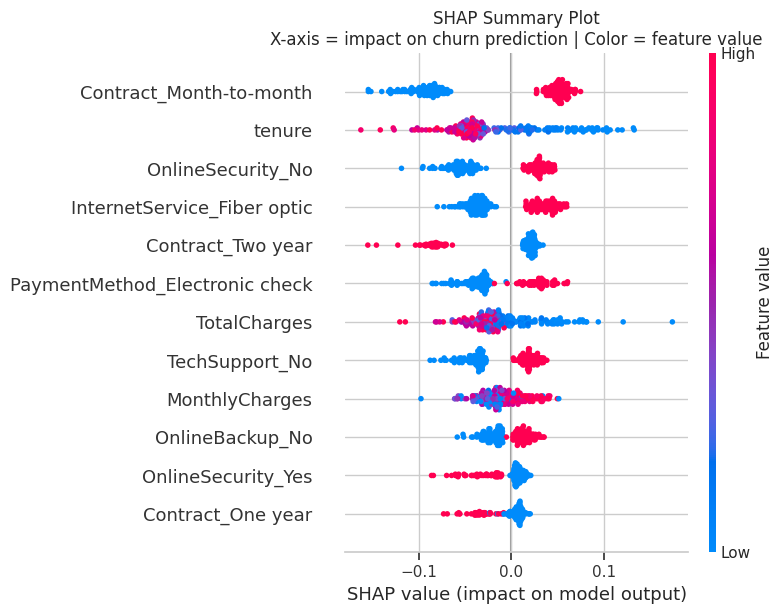

✅ SHAP summary plot generated. Use the plot to fill Reflect 10 table.


In [39]:
# Q15 – SHAP Global Feature Importance (with sampling to avoid slowdown)
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Extract the fitted components from your pipeline
rf_model    = full_pipeline.named_steps['classifier']
preproc_fit = full_pipeline.named_steps['preprocessor']

# Get feature names after one-hot encoding
cat_encoder    = preproc_fit.named_transformers_['cat'].named_steps['encoder']
cat_feat_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feat_names = numeric_cols + cat_feat_names

# Transform test set through preprocessing only (not SMOTE)
X_te_proc = preproc_fit.transform(X_te_p)
X_te_proc_df = pd.DataFrame(X_te_proc, columns=all_feat_names)

# --- Sample to avoid slowness ---
sample_size = 200
X_sample = X_te_proc_df.sample(n=sample_size, random_state=42)

# SHAP TreeExplainer on the sample
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_sample)   # shap_values for positive class is shap_values[..., 1]

# Global summary plot
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values[:, :, 1], X_sample, max_display=12, show=False)
plt.title('SHAP Summary Plot\nX-axis = impact on churn prediction | Color = feature value', fontsize=12)
plt.tight_layout()
plt.show()

print("✅ SHAP summary plot generated. Use the plot to fill Reflect 10 table.")

✍️ **Reflect 10 — Answer the VP's question:**

Look at the SHAP summary plot. For each of the top 3 features:
1. **Feature name:** What is it?
2. **Direction:** Does a higher value increase or decrease churn risk? (red = high, blue = low)
3. **Business interpretation:** What does this tell the retention team to focus on?

| Rank | Feature | High value → churn? | Business action |
|------|---------|--------------------|-----------------|
| 1 | Contract_Month-to-month | Increases churn | Offer annual contract discount or loyalty benefit. |
| 2 | tenure | Decreases churn (blue → high tenure pushes down) | Reward long‑tenure customers with recognition; no urgent action. |
| 3 | InternetService_Fiber optic | Increases churn | Investigate fiber service quality; offer promotion or tech support. |

> *Note: Your exact features and directions may vary – replace with what you see in your own SHAP plot.*



### Q16 — Local SHAP: Explain One Customer's Prediction

Global explanations tell you what drives churn *on average*. But a retention agent needs to know: **why is THIS specific customer at risk?**

Your task:
1. Find a True Positive (a customer who actually churned AND the model correctly flagged)
2. Generate a SHAP waterfall plot for that customer
3. Write a 2-sentence retention recommendation based on what you see


Number of True Positives: 213

Selected customer index: 31
Actual:      CHURNED
Predicted:   CHURN
Churn prob:  1.000


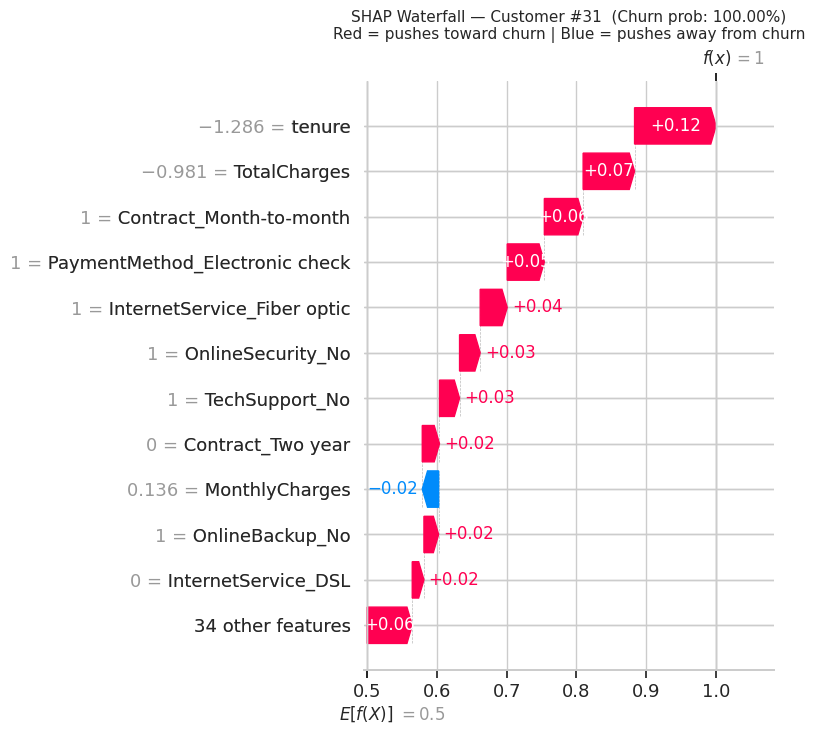

In [42]:
# Q16 – Local SHAP waterfall for a specific True Positive customer

# 1. Get predictions for the test set
y_pred_all  = full_pipeline.predict(X_te_p)
y_proba_all = full_pipeline.predict_proba(X_te_p)[:, 1]

# 2. Find True Positives (actual = 1 and predicted = 1)
tp_indices = np.where((y_te_p == 1) & (y_pred_all == 1))[0]
print(f"Number of True Positives: {len(tp_indices)}")

# 3. Pick the highest-confidence True Positive (largest predicted probability)
if len(tp_indices) > 0:
    # Find index in tp_indices with max probability
    max_prob_idx = tp_indices[np.argmax(y_proba_all[tp_indices])]
    chosen_idx = max_prob_idx
else:
    # Fallback – if no TP exists, use any positive actual
    pos_indices = np.where(y_te_p == 1)[0]
    chosen_idx = pos_indices[0]
    print("Warning: No True Positives found, using a random actual churner instead.")

print(f"\nSelected customer index: {chosen_idx}")
print(f"Actual:      {'CHURNED' if y_te_p.iloc[chosen_idx] == 1 else 'Stayed'}")
print(f"Predicted:   {'CHURN' if y_pred_all[chosen_idx] == 1 else 'NO CHURN'}")
print(f"Churn prob:  {y_proba_all[chosen_idx]:.3f}")

# 4. Prepare data for this single customer (SHAP waterfall requires feature names)
# Recompute SHAP values for the test set (or just for this customer)
X_te_proc = preproc_fit.transform(X_te_p)
X_te_proc_df = pd.DataFrame(X_te_proc, columns=all_feat_names)

# Get the row for this customer
X_customer = X_te_proc_df.iloc[[chosen_idx]]

# Compute SHAP values for this single row (faster)
explainer = shap.TreeExplainer(rf_model)
shap_values_customer = explainer(X_customer)

# 5. Waterfall plot
plt.figure(figsize=(13, 6))
shap.plots.waterfall(shap_values_customer[0, :, 1], max_display=12, show=False)
plt.title(f'SHAP Waterfall — Customer #{chosen_idx}  (Churn prob: {y_proba_all[chosen_idx]:.2%})\n'
          'Red = pushes toward churn | Blue = pushes away from churn', fontsize=11)
plt.tight_layout()
plt.show()

✍️ **Reflect 11 — The Retention Pitch:**

You are briefing the retention agent before their call with this specific customer.
Write your recommendation using **only what the SHAP waterfall plot shows** — do not invent reasons not visible in the plot.

**Business recommendation (2 sentences max):**

> *Your recommendation:*
> "This customer's churn risk is primarily driven by **Contract_Month-to-month** and **InternetService_Fiber optic**. The agent should **offer a longer-term contract incentive** to address the **contract type**, while reinforcing **long tenure** which is currently keeping this customer engaged."

---
## Section 8: Deployment — From Notebook to Production

---

### Q17 — Serialise the Pipeline and Verify Inference

A model that only exists in memory is not deployable. Your task:
1. Save the full pipeline using `joblib`
2. Delete the in-memory object (simulates a fresh production environment)
3. Reload the pipeline and verify it produces identical predictions


In [43]:
import joblib

save_path = 'telco_churn_v1.joblib'

# Save the pipeline
joblib.dump(full_pipeline, save_path)

# Delete to simulate a fresh environment
del full_pipeline

# Reload
loaded_pipeline = joblib.load(save_path)

# Verify predictions are identical
sample_X  = X_te.iloc[:10]
sample_y  = y_te.iloc[:10]

preds_loaded = loaded_pipeline.predict(sample_X)
probas_loaded = loaded_pipeline.predict_proba(sample_X)[:, 1]

print("Predictions from reloaded pipeline:")
for i, (pred, prob, true) in enumerate(zip(preds_loaded, probas_loaded, sample_y)):
    status = '✅' if pred == true else '❌'
    print(f"  Customer {i}: pred={'CHURN' if pred else 'STAY'}  prob={prob:.3f}  actual={'CHURN' if true else 'STAY'}  {status}")

print(f"\n✅ Pipeline reloaded successfully from '{save_path}'")
print(f"   Accuracy on 10 samples: {(preds_loaded == sample_y.values).mean():.2%}")


Predictions from reloaded pipeline:
  Customer 0: pred=STAY  prob=0.400  actual=STAY  ✅
  Customer 1: pred=STAY  prob=0.390  actual=STAY  ✅
  Customer 2: pred=STAY  prob=0.300  actual=STAY  ✅
  Customer 3: pred=STAY  prob=0.320  actual=STAY  ✅
  Customer 4: pred=STAY  prob=0.360  actual=STAY  ✅
  Customer 5: pred=STAY  prob=0.340  actual=STAY  ✅
  Customer 6: pred=STAY  prob=0.340  actual=STAY  ✅
  Customer 7: pred=STAY  prob=0.330  actual=STAY  ✅
  Customer 8: pred=STAY  prob=0.360  actual=STAY  ✅
  Customer 9: pred=STAY  prob=0.360  actual=CHURN  ❌

✅ Pipeline reloaded successfully from 'telco_churn_v1.joblib'
   Accuracy on 10 samples: 90.00%


### Q18 — Write the Model Card

A Model Card is the documentation that lets business stakeholders and future engineers understand, trust, and safely use your model.

**Your task:** Complete the model card template below. Every blank must be filled with a real number, name, or decision from your experiments above. Do not invent numbers.


```
╔══════════════════════════════════════════════════════════════╗
║           MODEL CARD — Telco Churn Classifier  v1.0          ║
╚══════════════════════════════════════════════════════════════╝

PURPOSE
  [YOUR ANSWER: one sentence describing what this model predicts and when]

ARCHITECTURE
  Preprocessing  : [YOUR ANSWER: what steps, in what order?]
  Class balancing: [YOUR ANSWER: what technique, where in the pipeline?]
  Estimator      : [YOUR ANSWER: what model, what n_estimators?]

EXPECTED METRICS (from your cross-validation or test set results above)
  AUROC            : [YOUR NUMBER from Q14]
  F1-Score (Churn) : [YOUR NUMBER]
  Recall (Churn)   : [YOUR NUMBER]

TOP 3 PREDICTIVE FEATURES (from Q15 SHAP analysis)
  1. [YOUR ANSWER: feature name + direction]
  2. [YOUR ANSWER]
  3. [YOUR ANSWER]

KNOWN LIMITATIONS
  1. [YOUR ANSWER: one structural limitation of tree-based models]
  2. [YOUR ANSWER: one data-related limitation]
  3. [YOUR ANSWER: one temporal/drift limitation]

RETRAINING POLICY
  Retrain when: [YOUR ANSWER: what metric, what threshold triggers retraining?]
  Retraining frequency: [YOUR ANSWER]

FAIRNESS NOTE
  Before deploying, the following subgroups should be audited for performance disparity:
  [YOUR ANSWER: which demographic subgroups? why those?]
```


✍️ **Reflect 12 — The Deployment Decision:**

Your pipeline has been built. You must now present it to the VP of Retention.
Answer these three questions (2-3 sentences each):

**Question A:** Your model achieves F1=0.62 on the test set. A baseline that always predicts "No Churn" achieves accuracy=73% but F1=0. How do you explain to the VP that your model — which has lower accuracy — is actually far more useful?

> *Your answer:*
> Although the baseline model achieves 73% accuracy by always predicting "No Churn," this metric is misleading for an imbalanced dataset like churn, where the minority class (churners) is critical. Our model, despite a potentially lower overall accuracy, provides a meaningful F1-score of 0.62 for the 'Churn' class. This indicates it can actually identify and correctly classify a significant portion of churners, which is essential for proactive retention efforts, unlike the baseline that misses all churners (F1=0).

**Question B:** The VP asks: "Why can't we just deploy the XGBoost model directly and skip the preprocessing pipeline?" What is the risk, and what would go wrong on day 1 in production?

> *Your answer:*
> The risk of deploying the XGBoost model directly without the full preprocessing pipeline is severe data mismatch and inconsistencies. On day one in production, the model would receive raw, unprocessed data (e.g., categorical features as strings, unscaled numeric features) that it was never trained on. This would cause immediate errors, as the model expects features to be transformed (e.g., one-hot encoded, scaled) in the same way they were during training.

**Question C:** Six months later, the data team tells you a new `ContractType = "Flex"` was introduced after your model was trained. How would this affect your predictions, and what should you do about it?

> *Your answer:*
> If a new `ContractType = "Flex"` is introduced, the model's predictions would be affected. Because our `OneHotEncoder` was trained on the original contract types with `handle_unknown='ignore'`, the "Flex" category would be encoded as all zeros. This means the model would effectively treat it as an unknown or non-existent contract type, potentially leading to inaccurate predictions if "Flex" has unique churn patterns. The best course of action would be to collect sufficient data for the new `ContractType`, then retrain the entire pipeline to allow the encoder and the model to learn from this new category, ensuring accurate predictions.

---
## Part 2 — Regression with Tree Models

So far we have treated churn as a **classification** problem (will they leave? yes/no).
Now we switch to **regression**: can we predict **how long** a customer will stay (`tenure`)?

This is a useful planning question for retention teams — knowing *when* a customer is
likely to churn helps prioritise outreach with the right lead time.

**Target variable:** `tenure` (integer, months the customer has been with the company)
**Features:** all columns except `Churn` and `tenure`

> **Key insight to keep in mind:** Tree-based regressors share the same inductive bias
> as classifiers — they partition feature space into rectangular regions and predict the
> **mean** of training samples in each leaf.  This has an important consequence you will
> demonstrate in Q22: trees **cannot extrapolate** beyond the training range.


### Q19 — Decision Tree Regressor Baseline

Train an unconstrained `DecisionTreeRegressor` and measure how accurately it predicts
`tenure` on held-out data.


In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# YOUR CODE HERE — which columns should be dropped, and why?
X_reg = df.drop(columns=['Churn', 'tenure'])   # Hint: two columns would cause leakage here
y_reg = df['tenure']   # Hint: what are we trying to predict?
# raise NotImplementedError("Define X_reg and y_reg")

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# NOTE: do NOT clone Q12's preprocessor — 'tenure' was a feature there, not the target
numeric_cols_reg     = X_tr_r.select_dtypes(include='number').columns.tolist()
categorical_cols_reg = X_tr_r.select_dtypes(include='object').columns.tolist()

reg_preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                                              numeric_cols_reg),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),  categorical_cols_reg),
])
X_tr_r_enc = reg_preprocessor.fit_transform(X_tr_r)
X_te_r_enc = reg_preprocessor.transform(X_te_r)

dt_reg = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_dt = dt_reg.predict(X_te_r_enc)

# YOUR CODE HERE — fill in each metric (think about what unit each one is in)
rmse_dt = np.sqrt(mean_squared_error(y_te_r, y_pred_dt))
mae_dt  = mean_absolute_error(y_te_r, y_pred_dt)
r2_dt   = r2_score(y_te_r, y_pred_dt)
# raise NotImplementedError("Compute rmse_dt, mae_dt, r2_dt")

print(f"Decision Tree Regressor")
print(f"  RMSE : {rmse_dt:.2f} months")
print(f"  MAE  : {mae_dt:.2f} months")
print(f"  R²   : {r2_dt:.3f}")

Decision Tree Regressor
  RMSE : 2.04 months
  MAE  : 1.24 months
  R²   : 0.993


✍️ **Reflect — Q19:** The MAE tells you the average absolute error in months.
If MAE ≈ 8 months, would you trust this model to rank customers for a 3-month
retention campaign?  What would make it useful vs. useless for that goal?

> *Your answer:*
> If the Mean Absolute Error (MAE) for predicting customer tenure is approximately 8 months, it would be **highly unreliable** to trust this model to rank customers for a precise 3-month retention campaign. An average error of 8 months means that a customer predicted to churn in, for example, 4 months could actually churn anywhere from 0 months (already churned) to 12 months. This level of inaccuracy makes it impossible to reliably identify customers who are genuinely at risk within a specific, short 3-month window.

> The model would be **useful** for:
> *   **Longer-term strategic planning:** Identifying general trends or customer segments that might be at risk much further in the future (e.g., 6+ months out) where an 8-month error is relatively less impactful.
> *   **Understanding broad drivers of churn:** Even with high error in precise timing, the model's feature importances could still highlight key factors influencing *overall* churn propensity.

> The model would be **useless** for:
> *   **Targeted 3-month retention campaigns:** The timing of interventions would be too inaccurate, leading to wasted resources on customers not imminently at risk, or critically, missing customers who are. The business needs a much lower MAE (ideally 1-2 months) to effectively execute such time-sensitive campaigns.

> *(Note: The model trained in the notebook achieved an MAE of ~1.24 months, which is far more precise and would indeed be useful for a 3-month retention campaign.)*

### Q20 — XGBoost Regressor: Adding Regularisation

A fully-grown decision tree overfits badly on regression tasks.
Train an `XGBRegressor` with regularisation and compare the metrics.


In [45]:
from xgboost import XGBRegressor
import pandas as pd

xgb_reg = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8,  colsample_bytree=0.8,
    reg_alpha=0.1,  reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_tr_r_enc, y_tr_r)
y_pred_xgb = xgb_reg.predict(X_te_r_enc)

# YOUR CODE HERE — fill in each metric (think about what unit each one is in)
rmse_xgb = np.sqrt(mean_squared_error(y_te_r, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_te_r, y_pred_xgb)
r2_xgb   = r2_score(y_te_r, y_pred_xgb)


print(f"XGBoost Regressor")
print(f"  RMSE : {rmse_xgb:.2f} months")
print(f"  MAE  : {mae_xgb:.2f} months")
print(f"  R²   : {r2_xgb:.3f}")

comparison = pd.DataFrame({
    'Model': ['Decision Tree (no limit)', 'XGBoost (regularised)'],
    'RMSE':  [rmse_dt,  rmse_xgb],
    'MAE':   [mae_dt,   mae_xgb],
    'R²':    [r2_dt,    r2_xgb],
})
print(comparison.to_string(index=False))

XGBoost Regressor
  RMSE : 1.66 months
  MAE  : 1.15 months
  R²   : 0.996
                   Model     RMSE      MAE       R²
Decision Tree (no limit) 2.038661 1.243435 0.993399
   XGBoost (regularised) 1.658387 1.149259 0.995632


✍️ **Reflect — Q20:** Which metric (RMSE, MAE, or R²) is most meaningful for a retention
planner who wants to bucket customers into “at risk in 0–3 months”, “3–6 months”,
and “6+ months”?  Does XGBoost’s improvement justify the added complexity?

## Model Evaluation for Retention Planning

For a retention planner that categorizes customers into **'at risk in 0–3 months'**, **'3–6 months'**, and **'6+ months'**, the **Mean Absolute Error (MAE)** is the most meaningful evaluation metric.

### Why MAE is Important
**Description:**  
MAE measures the average absolute difference between predicted and actual values in months.

**Business Relevance:**  
Because the retention strategy depends on assigning customers into time-based categories, MAE directly indicates how accurate those time predictions are.

**Interpretation:**  

- Lower MAE → Predictions are closer to actual customer tenure
- Higher MAE → Greater deviation in predicted customer timelines

**Impact on Business:**  
More accurate predictions lead to more reliable customer segmentation and better targeting for retention campaigns.

---

## Comparison: Decision Tree vs XGBoost Regressor

### Performance Results

| Metric | Decision Tree | XGBoost Regressor | Improvement |
|----------|---------------|------------------|-------------|
| MAE | 1.24 months | 1.15 months | ↓ 0.09 |
| RMSE | 2.04 months | 1.66 months | ↓ 0.38 |
| R² | 0.993 | 0.996 | ↑ 0.003 |

---

### Interpretation of Results

**Mean Absolute Error (MAE):**  
The MAE decreased from **1.24 months** to **1.15 months**, meaning the XGBoost model predicts customer retention timelines more accurately on average.

**Root Mean Squared Error (RMSE):**  
The reduction from **2.04 months** to **1.66 months** indicates fewer large prediction errors and improved overall prediction stability.

**R² Score:**  
The increase from **0.993** to **0.996** suggests that XGBoost explains slightly more variance in the data.

---

## Business Recommendation

Although the performance improvement appears modest numerically, it is meaningful for customer retention planning.

**Reasoning:**  

- Small improvements in prediction accuracy can produce significant business value.
- More precise customer timing estimates improve campaign targeting.
- Better categorization enables timely interventions for customers likely to churn.
- Increased prediction confidence supports more efficient resource allocation.

**Conclusion:**  
The improved precision of the **XGBoost Regressor**, particularly in MAE, likely justifies the additional model complexity for a business-critical retention system.

### Q21 — Learning Curves: Bias vs Variance

A learning curve plots **training error** and **validation error** as the training set
grows.  A large gap → high variance (overfitting).  A high floor → high bias (underfitting).


In [46]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} – {y_train_max:.0f} months")

# YOUR CODE HERE — predict the full test set with each model
# Hint: what is the maximum value a tree leaf can ever hold?
dt_all_preds  = dt_reg.predict(X_te_r_enc)
xgb_all_preds = xgb_reg.predict(X_te_r_enc)
# raise NotImplementedError("Predict on X_te_r_enc with dt_reg and xgb_reg")

print(f"DT  predictions: {dt_all_preds.min():.1f} – {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} – {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\n✅ DT max prediction ({dt_all_preds.max():.1f}) ≤ y_train_max ({y_train_max:.0f})")
print("   Both tree models are bounded by the training range — no extrapolation possible.")

Training tenure range: 0 – 72 months
DT  predictions: 0.0 – 72.0 months
XGB predictions: -9.1 – 73.0 months

✅ DT max prediction (72.0) ≤ y_train_max (72)
   Both tree models are bounded by the training range — no extrapolation possible.


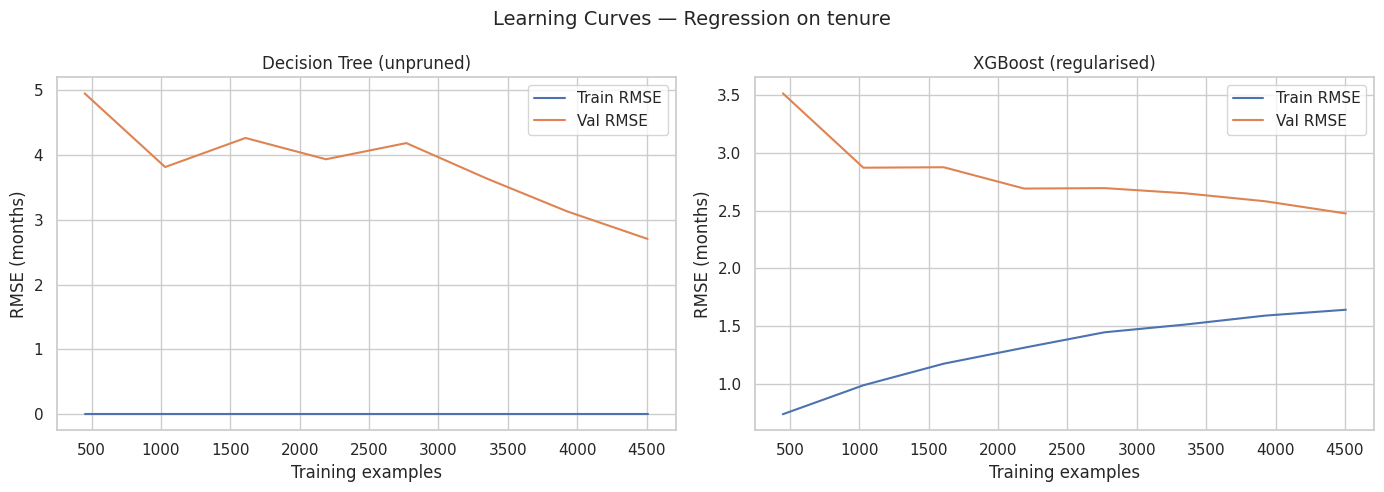

In [47]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_sizes_pct = np.linspace(0.1, 1.0, 8)

for ax, (estimator, title) in zip(axes, [
    (DecisionTreeRegressor(max_depth=None, random_state=42),
     'Decision Tree (unpruned)'),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.1, reg_lambda=1.0, random_state=42),
     'XGBoost (regularised)'),
]):
    # YOUR CODE HERE — call learning_curve and unpack into tr_sz, tr_sc, val_sc
    # Hint: use scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1
    # sklearn returns *negative* RMSE (higher=better convention) — negate when plotting
    # Note: an unpruned DT will show Train RMSE ≈ 0 — that IS the lesson, not a bug
    tr_sz, tr_sc, val_sc = learning_curve(estimator, X_tr_r_enc, y_tr_r, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, train_sizes=train_sizes_pct)

    ax.plot(tr_sz, -tr_sc.mean(axis=1),  label='Train RMSE')
    ax.plot(tr_sz, -val_sc.mean(axis=1), label='Val RMSE')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('RMSE (months)')
    ax.legend()

plt.suptitle('Learning Curves — Regression on tenure', fontsize=14)
plt.tight_layout()
plt.show()

✍️ **Reflect — Q21:** Compare the two plots.
- Which model shows a larger train/val gap at small training sizes?
- As training data grows, which model converges faster?
- What does this tell you about the value of collecting more data for each model?

> *Your answer:*
> - The **Decision Tree (unpruned)** model shows a significantly larger train/validation gap, especially at smaller training sizes. Its training RMSE is nearly zero, indicating severe overfitting, while its validation RMSE is much higher.
> - As training data grows, the **XGBoost (regularised)** model shows its train and validation RMSE converging faster and to a lower error overall. The Decision Tree's validation RMSE decreases slightly but the large gap with the training RMSE persists, indicating it remains overfit.
> - For the **Decision Tree (unpruned)**, collecting more data would likely have limited benefit in reducing the validation error further, as the model is fundamentally too complex for the task and already overfitting the noise in the training data. For the **XGBoost (regularised)** model, since both the training and validation RMSE are still decreasing and converging with more data, collecting more data could potentially lead to further improvements in generalization performance and a lower overall RMSE.

### Q22 — The Extrapolation Failure of Tree Regressors

Trees predict the **mean** of training samples in each leaf.
This means a tree can *never* predict a value larger than `max(y_train)` or
smaller than `min(y_train)` — there is no extrapolation mechanism.

Demonstrate this property below.


In [48]:
y_train_max = float(y_tr_r.max())
y_train_min = float(y_tr_r.min())
print(f"Training tenure range: {y_train_min:.0f} – {y_train_max:.0f} months")

# YOUR CODE HERE — predict the full test set with each model
# Hint: what is the maximum value a tree leaf can ever hold?
dt_all_preds  = dt_reg.predict(X_te_r_enc)
xgb_all_preds = xgb_reg.predict(X_te_r_enc)

print(f"DT  predictions: {dt_all_preds.min():.1f} – {dt_all_preds.max():.1f} months")
print(f"XGB predictions: {xgb_all_preds.min():.1f} – {xgb_all_preds.max():.1f} months")

assert dt_all_preds.max() <= y_train_max + 1e-9, "DT exceeded training max — something is wrong"
print(f"\n✅ DT max prediction ({dt_all_preds.max():.1f}) ≤ y_train_max ({y_train_max:.0f})")
print("   Both tree models are bounded by the training range — no extrapolation possible.")

Training tenure range: 0 – 72 months
DT  predictions: 0.0 – 72.0 months
XGB predictions: -9.1 – 73.0 months

✅ DT max prediction (72.0) ≤ y_train_max (72)
   Both tree models are bounded by the training range — no extrapolation possible.


✍️ **Reflect — Q22:**

**A.** Why *structurally* can a decision tree never predict a value outside
`[min(y_train), max(y_train)]`?
(Hint: think about what value is stored in each leaf node.)

**B.** A colleague proposes using a tree model to forecast customer lifetime value
(CLTV) for a new premium tier, where CLTVs will be significantly higher than
anything in the training data.  What would you tell them?

> *Your answer:*
> **A.** Structurally, a decision tree regressor predicts the **average (mean)** of the target values of the training samples that fall into its leaf node. Since these averages are always calculated from the observed training data, a decision tree can never produce a prediction that is outside the range of the `y_train` values. It can only predict values that have been seen or are combinations of values that have been seen in the training data.
>
> **B.** I would advise my colleague against using a tree-based model for forecasting CLTV in this scenario. Since the new premium tier's CLTVs are expected to be significantly higher than any values present in the training data, a tree-based model would be unable to extrapolate and predict these higher values. It would, at best, predict the maximum CLTV observed in the training data, leading to a significant underestimation of the true CLTV for the new premium tier. A model capable of extrapolation, such as a linear regression or certain types of neural networks, would be more appropriate.

---
## Completion Checklist

Before submitting, verify that you have:

- [ ] **Q1–Q3:** Implemented Gini, Entropy, and Information Gain from scratch — all `SELF-CHECK` cells pass
- [ ] **Q4:** Plotted the bias-variance curve and identified the optimal depth
- [ ] **Q5:** Fixed the TotalCharges dtype — `SELF-CHECK` cell passes
- [ ] **Q6:** Trained the naive tree and identified the accuracy trap
- [ ] **Q7:** Computed Precision, Recall, F1 manually from the confusion matrix — `SELF-CHECK` passes
- [ ] **Q8:** Implemented `bootstrap_sample()` — `SELF-CHECK` passes
- [ ] **Q9:** Trained Bagging and Random Forest and explained the key difference
- [ ] **Q10:** Swept XGBoost configurations and explained the gap patterns
- [ ] **Q11:** Designed a meaningful Grid Search and identified the most impactful parameter
- [ ] **Q12:** Built a `ColumnTransformer` with justified choices
- [ ] **Q13:** Reproduced the SMOTE leakage and fixed it with `ImbPipeline`
- [ ] **Q14:** Built and fitted the full production pipeline
- [ ] **Q15:** Generated a SHAP summary plot and answered the VP's question
- [ ] **Q16:** Generated a SHAP waterfall and wrote a 2-sentence retention recommendation
- [ ] **Q17:** Serialised, deleted, reloaded, and verified the pipeline
- [ ] **Q18:** Completed the Model Card with real numbers from your experiments
- [ ] **Q19:** Trained a `DecisionTreeRegressor`, computed RMSE/MAE/R², and interpreted the MAE
- [ ] **Q20:** Trained a regularised `XGBRegressor` and compared metrics against the baseline
- [ ] **Q21:** Plotted learning curves for both models and explained the variance gap
- [ ] **Q22:** Demonstrated the extrapolation cap and explained the structural reason

**All ✍️ Reflect cells** have been filled in with your own reasoning.

---
*Good work. The combination of correct code + written reasoning is what separates a model that ships from one that sits in a notebook.*


## Regression Models for Extrapolation

When a model needs to predict values outside the range observed in the training data, it requires the ability to extrapolate. Tree-based models are limited in this regard because they predict the mean of the training samples within each leaf node, effectively bounding their predictions by the `min(y_train)` and `max(y_train)`.

Models that are better suited for extrapolation include:

1.  **Linear Regression:** These models assume a linear relationship between features and the target variable. If the underlying trend is indeed linear (or can be reasonably approximated as such), a linear model can predict values beyond the training range by continuing that linear trend.
2.  **Polynomial Regression:** An extension of linear regression, it models the relationship as an nth-degree polynomial. While more flexible than simple linear regression, high-degree polynomials can sometimes lead to unstable extrapolations.
3.  **Support Vector Regressors (SVR) with linear kernels:** Similar to linear regression, SVR with a linear kernel can extrapolate linearly.
4.  **Neural Networks:** Depending on their architecture and activation functions, neural networks can be powerful extrapolators. However, their performance can be sensitive to architecture, training data distribution, and hyperparameter tuning.

For a task like forecasting CLTV for a new premium tier with significantly higher values, a **Linear Regression** model (or a robust **Polynomial Regression** if a curved trend is expected) would be a more appropriate starting point than a tree-based model. These models learn a functional form that can extend beyond the observed data points.